<a href="https://colab.research.google.com/github/AfsanaMim9639/ML-Assignment/blob/main/Sentiment_Analysis_on_Amazon_Product_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on Amazon Product Reviews

## 1. Dataset Overview
- **Dataset Description**:
  - Analyze an Amazon product review dataset containing textual reviews (`reviewText`) and corresponding sentiment labels (`Positive`).
  - Sentiment is binary: 1 for positive, 0 for negative.
- **Objective**:
  - Predict the sentiment of a product review based on its textual content.


In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/amazon.csv'
df = pd.read_csv(url)
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


<br><br><br>

# <font color='green'>Solution Start</font>

## 2. Data Preprocessing
- Handle missing values, if any.
- Perform text preprocessing on the `reviewText` column:
  - Convert text to lowercase.
  - Remove stop words, punctuation, and special characters.
  - Tokenize and lemmatize text data.
- Split the dataset into training and testing sets.


## <font color='red'><li>Handle missing values</li></font>

In [3]:
# Check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [4]:
df.isnull().sum()

,0
reviewText,0
Positive,0


## <font color='red'><li>Perform text preprocessing </li></font>

1. Convert to lowercase

2. Remove punctuation and special characters

3. Remove stopwords

4. Tokenize

5. Lemmatize

In [5]:
## Import All Required Libraries
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data (only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Step 1: Lowercase conversion
df['lower'] = df['reviewText'].str.lower()

# Step 2: Remove punctuation and special characters
df['no_punct'] = df['lower'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Step 3: Tokenization
df['tokens'] = df['no_punct'].apply(word_tokenize)

# Step 4: Remove stopwords
df['no_stopwords'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Step 5: Lemmatization
df['lemmatized'] = df['no_stopwords'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Step 6: Join back into string if needed
df['cleaned_review'] = df['lemmatized'].apply(lambda x: ' '.join(x))


In [8]:
df[['reviewText', 'cleaned_review']].head()


,reviewText,cleaned_review
0,This is a one of the best apps acording to a b...,one best apps acording bunch people agree bomb...
1,This is a pretty good version of the game for ...,pretty good version game free lot different le...
2,this is a really cool game. there are a bunch ...,really cool game bunch level find golden egg s...
3,"This is a silly game and can be frustrating, b...",silly game frustrating lot fun definitely reco...
4,This is a terrific game on any pad. Hrs of fun...,terrific game pad hr fun grandkids love great ...



## <font color='red'><li>Split the dataset into training and testing sets.</li></font>

In [9]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df['cleaned_review']
y = df['Positive']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42,
    stratify=y
)

# Check the size
print("Training size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 16000
Testing size: 4000


<br>

## 3. Model Selection
- Choose at least three machine learning models for sentiment classification:
  - Statistical Models:
    - Logistic Regression
    - Random Forest
    - Support Vector Machine (SVM)
    - Naïve Bayes
    - Gradient Boosting (e.g., XGBoost, AdaBoost, CatBoost)
  - Neural Models:
    - LSTM (Long Short-Term Memory)
    - GRUs (Gated Recurrent Units)


**Note: I will choose Logistic Regression, SVM and Gradient Boosting (XGBoost)**

## <font color='red'><li>Statistical Models:</li></font>

In [10]:
## Import all libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
## TF-IDF Vectorization
# Vectorize the cleaned text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  #  can increase features if needed
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


### <font color='green'><li>Train and Evaluate Each Model</li></font>
#### <font color='black'>1. Logistic Regression</font>

In [12]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.85      0.65      0.74       953
           1       0.90      0.96      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.87      0.81      0.83      4000
weighted avg       0.89      0.89      0.88      4000



#### <font color='black'>2. Support Vector Machine (Linear SVC)</font>

In [13]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Report:")
print(classification_report(y_test, y_pred_svm))


SVM Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       953
           1       0.92      0.94      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.86      0.84      0.85      4000
weighted avg       0.89      0.90      0.89      4000



#### <font color='black'>3.  XGBoost</font>

In [14]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb.predict(X_test_tfidf)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:41:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Report:
              precision    recall  f1-score   support

           0       0.82      0.59      0.68       953
           1       0.88      0.96      0.92      3047

    accuracy                           0.87      4000
   macro avg       0.85      0.77      0.80      4000
weighted avg       0.87      0.87      0.86      4000



## Plot Confusion Matrix

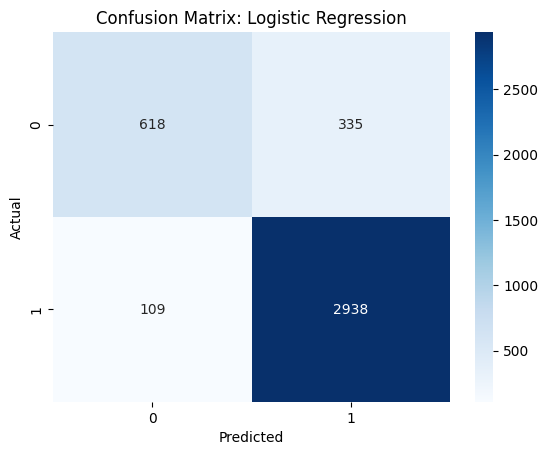

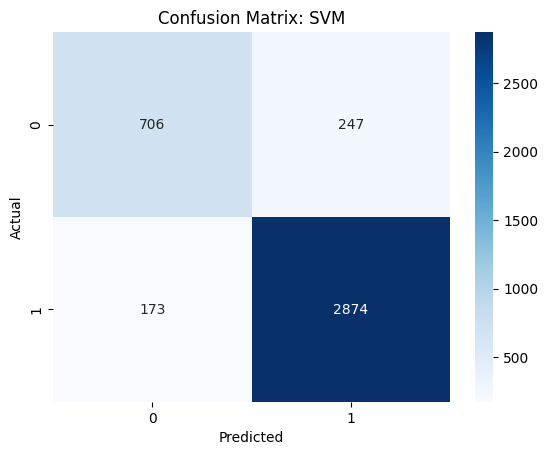

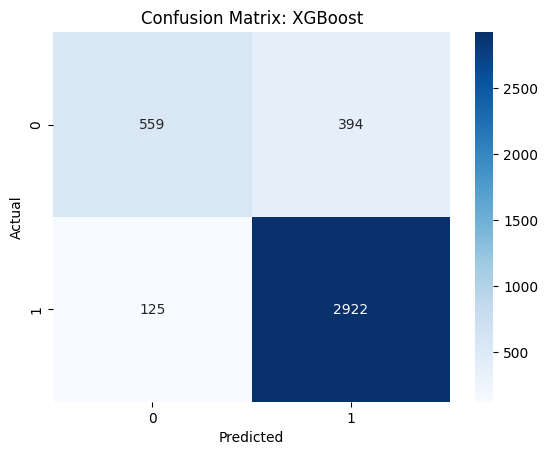

In [15]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot for each model
plot_conf_matrix(y_test, y_pred_lr, 'Logistic Regression')
plot_conf_matrix(y_test, y_pred_svm, 'SVM')
plot_conf_matrix(y_test, y_pred_xgb, 'XGBoost')


## <font color='red'><li>Neural Network- GRU</li></font>

In [16]:
## Install and Import Required Libraries

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [17]:
## Tokenize and Pad the Text Data
# Parameters
vocab_size = 10000
max_len = 100  # max number of words in a review

# Tokenize
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')



In [18]:
## Build the GRU Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_len,)),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification output
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,049 (2.63 MB)

 Trainable params: 690,049 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
## Train the Model
history = model.fit(X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=2
)


Epoch 1/5
225/225 - 38s - 171ms/step - accuracy: 0.8439 - loss: 0.3589 - val_accuracy: 0.8831 - val_loss: 0.2755
Epoch 2/5
225/225 - 44s - 194ms/step - accuracy: 0.9197 - loss: 0.2048 - val_accuracy: 0.8944 - val_loss: 0.2536
Epoch 3/5
225/225 - 34s - 151ms/step - accuracy: 0.9467 - loss: 0.1471 - val_accuracy: 0.8869 - val_loss: 0.2972
Epoch 4/5
225/225 - 42s - 187ms/step - accuracy: 0.9621 - loss: 0.1096 - val_accuracy: 0.8856 - val_loss: 0.3333
Epoch 5/5
225/225 - 41s - 182ms/step - accuracy: 0.9726 - loss: 0.0828 - val_accuracy: 0.8794 - val_loss: 0.3958


In [20]:
#Evaluate on Test Data
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8778 - loss: 0.3978
Test Accuracy: 0.8825


In [21]:
# Predict and Generate Classification Report
import numpy as np
from sklearn.metrics import classification_report

y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       953
           1       0.91      0.94      0.92      3047

    accuracy                           0.88      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.88      0.88      0.88      4000



## 4. Model Training
- Train each selected model on the training dataset.
- Utilize vectorization techniques for text data:
  - TF-IDF (Term Frequency-Inverse Document Frequency)
  - Word embeddings (e.g., Word2Vec, GloVe)


## <font color='red'><li>Train each selected model on the training dataset.</li></font>
**Note:  I've already done this section**
<br><br>


## <font color='red'><li>Utilize vectorization techniques for text data:</li></font>

**Note: I've done TF-IDF (Term Frequency-Inverse Document Frequency) in the previous section**



## 5. Formal Evaluation
- Evaluate the performance of each model on the testing set using the following metrics:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - Confusion Matrix


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [23]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n Evaluation for: {model_name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step

 Evaluation for: Logistic Regression
Accuracy : 0.889
Precision: 0.8976474182706997
Recall   : 0.9642271086314408
F1 Score : 0.9297468354430379

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.65      0.74       953
           1       0.90      0.96      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.87      0.81      0.83      4000
weighted avg       0.89      0.89      0.88      4000



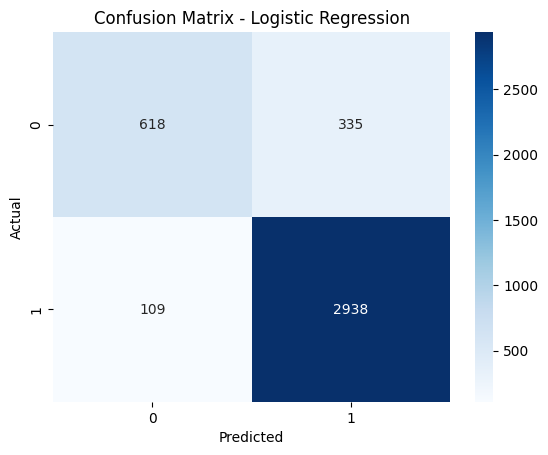


 Evaluation for: Support Vector Machine (SVM)
Accuracy : 0.895
Precision: 0.9208586991348927
Recall   : 0.9432228421398097
F1 Score : 0.9319066147859922

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       953
           1       0.92      0.94      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.86      0.84      0.85      4000
weighted avg       0.89      0.90      0.89      4000



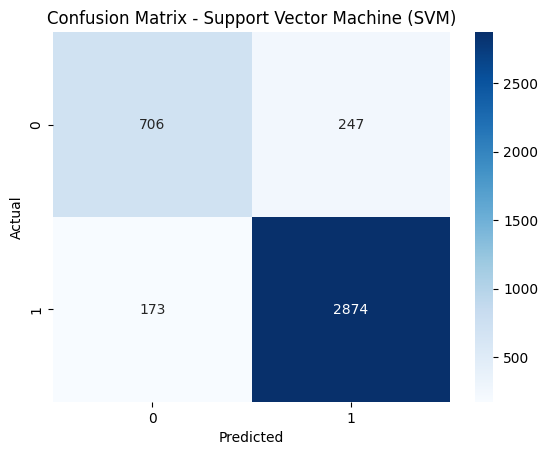


 Evaluation for: XGBoost
Accuracy : 0.87025
Precision: 0.8811821471652593
Recall   : 0.958976042008533
F1 Score : 0.9184347006129184

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.59      0.68       953
           1       0.88      0.96      0.92      3047

    accuracy                           0.87      4000
   macro avg       0.85      0.77      0.80      4000
weighted avg       0.87      0.87      0.86      4000



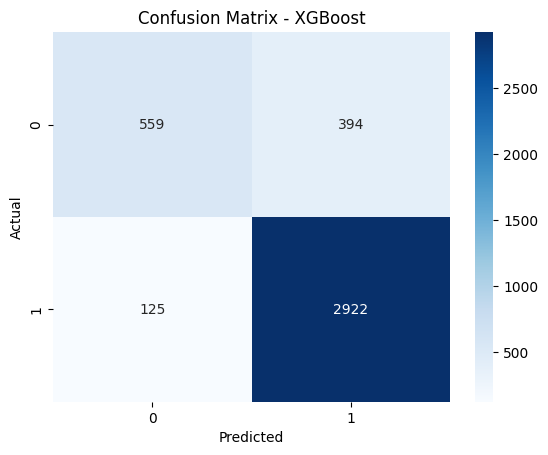


 Evaluation for: GRU Neural Network
Accuracy : 0.8825
Precision: 0.912848446010894
Recall   : 0.9350180505415162
F1 Score : 0.9238002594033723

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74       953
           1       0.91      0.94      0.92      3047

    accuracy                           0.88      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.88      0.88      0.88      4000



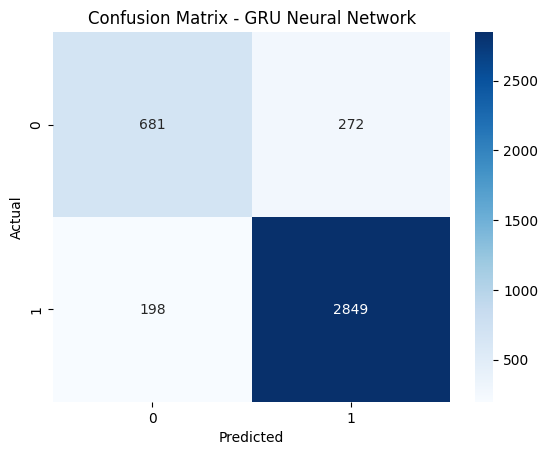

In [24]:
# Get probabilities (between 0 and 1)
y_pred_proba_gru = model.predict(X_test_pad)
# Convert to binary class (threshold 0.5)
y_pred_gru = (y_pred_proba_gru > 0.5).astype(int).flatten()

# Traditional ML models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_svm, "Support Vector Machine (SVM)")
evaluate_model(y_test, y_pred_xgb, "XGBoost")

# GRU Model (Neural Net)
evaluate_model(y_test, y_pred_gru, "GRU Neural Network")


## 6. Hyperparameter Tuning
- Perform hyperparameter tuning for selected models using:
  - Grid Search
  - Random Search
- Explain the chosen hyperparameters and justify their selection.


## Grid Search with GridSearchCV

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.8898124327371136

 Evaluation for: Tuned Logistic Regression
Accuracy : 0.89525
Precision: 0.9206145966709347
Recall   : 0.9438792254676731
F1 Score : 0.9321017663263652

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       953
           1       0.92      0.94      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.86      0.84      0.85      4000
weighted avg       0.89      0.90      0.89      4000



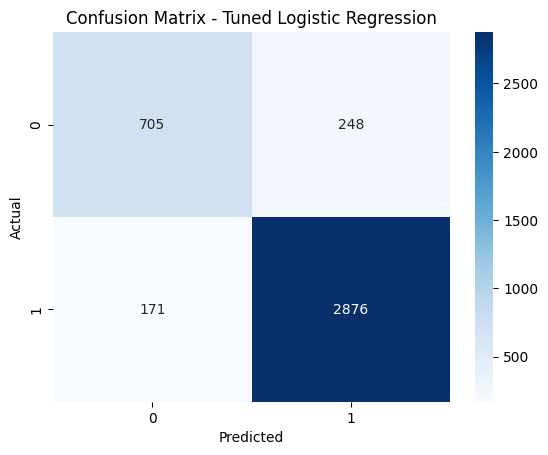

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],   # l1 not supported by default solver
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_lr = grid.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_best_lr, "Tuned Logistic Regression")


## Random Search with RandomizedSearchCV

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
import numpy as np


In [27]:
param_dist = {
    'C': np.logspace(-3, 2, 6),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}



In [28]:
random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train_tfidf, y_train)


RandomizedSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]),
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='accuracy')

In [29]:

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)


Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': np.float64(100.0)}
Best CV Accuracy: 0.8934372726191899



 Evaluation for: Tuned SVM
Accuracy : 0.89925
Precision: 0.9141604010025063
Recall   : 0.957663275352806
F1 Score : 0.9354063151146017

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       953
           1       0.91      0.96      0.94      3047

    accuracy                           0.90      4000
   macro avg       0.88      0.84      0.85      4000
weighted avg       0.90      0.90      0.90      4000



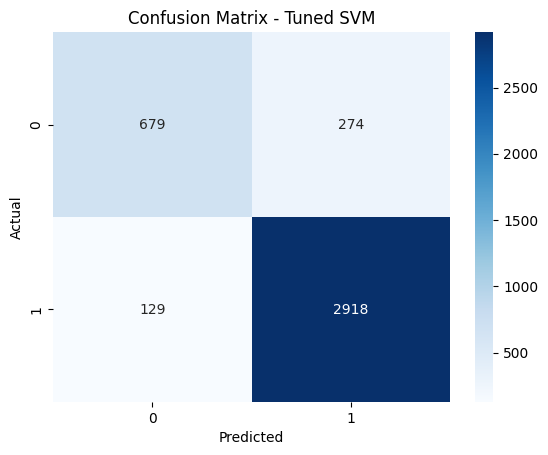

In [30]:

best_svm = random_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_best_svm, "Tuned SVM")

## For XGBoost

In [31]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1]
}



In [32]:

grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_tfidf, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:12:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 1]},
             scoring='accuracy')

In [33]:
print("Best Params:", grid_xgb.best_params_)
print("Best CV Accuracy:", grid_xgb.best_score_)


Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
Best CV Accuracy: 0.8771874287324809



 Evaluation for: Tuned XGBoost
Accuracy : 0.878
Precision: 0.8960074280408542
Recall   : 0.9501148670823761
F1 Score : 0.9222682382924499

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.65      0.72       953
           1       0.90      0.95      0.92      3047

    accuracy                           0.88      4000
   macro avg       0.85      0.80      0.82      4000
weighted avg       0.87      0.88      0.87      4000



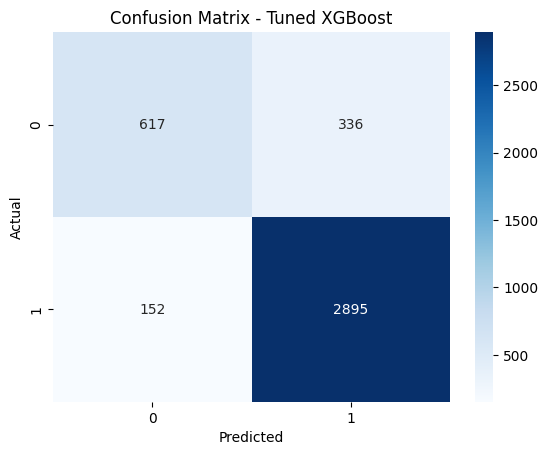

In [34]:
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_best_xgb, "Tuned XGBoost")

## 7. Comparative Analysis
- Compare the performance of all models based on evaluation metrics.
- Identify strengths and weaknesses of each model (e.g., speed, accuracy, interpretability).


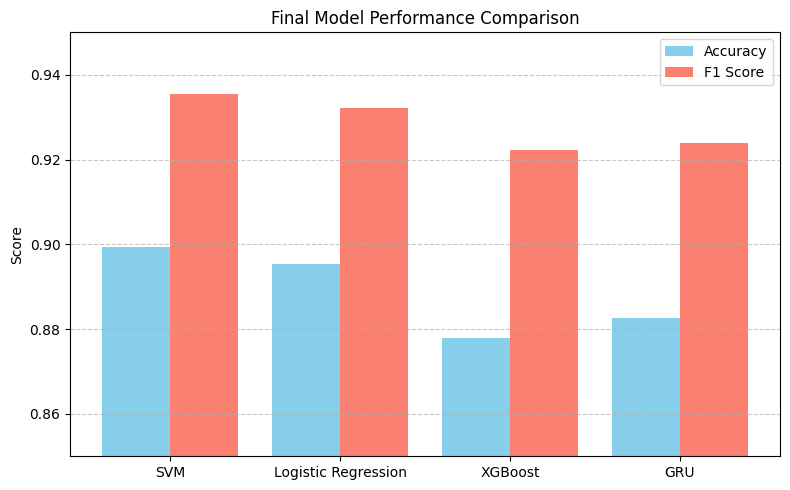

In [36]:
import matplotlib.pyplot as plt

models = ['SVM', 'Logistic Regression', 'XGBoost', 'GRU']
accuracy = [0.89925, 0.89525, 0.878, 0.8825]
f1_scores = [0.9354, 0.9321, 0.9223, 0.9238]

x = range(len(models))
plt.figure(figsize=(8, 5))
plt.bar(x, accuracy, width=0.4, label='Accuracy', align='center', color='skyblue')
plt.bar([i + 0.4 for i in x], f1_scores, width=0.4, label='F1 Score', color='salmon')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel('Score')
plt.title('Final Model Performance Comparison')
plt.legend()
plt.ylim(0.85, 0.95)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##  Strengths and weaknesses of each model (e.g., speed, accuracy, interpretability)



| Model             | Speed     | Accuracy | Interpretability | Best Use Case                             |
| ----------------- | --------- | -------- | ---------------- | ----------------------------------------- |
| **SVM**           | Slow    |  High   |  Low            | Maximum performance, small-medium data    |
| **Logistic Reg.** | Fast    |  High   |  High           | Prototypes, dashboards, interpretable AI  |
| **XGBoost**       | Medium |  High   |  Medium        | Production-ready, tabular/text-heavy apps |
| **GRU**           |  Slow    |  High   |  Low            | Deep NLP, sequential text, RNN tasks      |


## 8. Conclusion & Comments
- Summarize the findings of the project.
- Provide insights into the challenges faced during data preprocessing, model training, and evaluation.
- Highlight key lessons learned.
- Add clear and concise comments to the code for each step of the project.
- Highlight key results, visualizations, and model comparisons.
